<a href="https://colab.research.google.com/github/shrivatsasamyukta-sketch/ev-adoption/blob/main/EV_Adoption_CodingSchoolProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# **Project Info**

### *Acronyms*

BEV - Battery-Powered Electric Vehicles

PHEV - Plug-in Hybrid Electric Vehicles

HEV - Hybrid Electric Vehicles

### *Notes*

BEVs have larger batteries but less overall mileage per charge

PHEVs have smaller batteries so have less miles on their electric charges but much more through traditional gas refills

HEVs as a whole aren't covered in this dataset but traditional HEVs recharge through a regenerative braking system and have much smaller batteries, but don't need to be recharged through a regular charging system.

Dataset also includes data from outside the US and US territories, and doesn't have data from all states in the US

---

## ***Copy and Pasted Info***

### *Topic Overview*

The transition to electric vehicles (EVs) is a central strategy in the effort to reduce dependence on oil. However, the adoption of EVs varies significantly by geography, income, vehicle type, and access to charging infrastructure. State-level data offers valuable insight into the pace and pattern of this transition.
This project invites students to explore the population of electric vehicles registered in Washington State. By analyzing vehicle registration data, students will investigate where EV adoption is most common, which vehicle types dominate the market, and how electric range and pricing correlate with geographic and demographic indicators. This dataset provides a rich opportunity to examine the intersection of clean energy policy, transportation infrastructure, and environmental equity.

### *Dataset Description*

This dataset provides a regularly updated list of registered electric vehicles (EVs) in Washington State, as recorded by the Washington State Department of Licensing. Each row represents one electric vehicle registration and includes details about the vehicle, its location, and eligibility for clean fuel incentives.

This dataset supports exploration of EV distribution by region, vehicle type diversity, pricing trends, and access to clean vehicle incentives. It can also be joined with demographic or census data to explore equity in EV adoption.

### *Key Features*

Geographic Detail:
* County, City, State, ZIP Code
* Legislative District
* 2020 Census Tract (enables connection to demographic data)
* Electric Utility service area

Vehicle Details:
* VIN (anonymized to the first 10 characters)
* Make and Model
* Model Year
* Electric Vehicle Type (Battery Electric Vehicle, Plug-in Hybrid, etc.)
* Electric Range (in miles)
* Base MSRP (manufacturer’s suggested retail price)

Incentive and Policy Fields:
* CAFV (Clean Alternative Fuel Vehicle) eligibility status
* Utility service provider (relevant for infrastructure and rebate programs)

Coverage:
* State: Washington
* Unit of Analysis: Individual electric vehicle registration
* Frequency: Periodically updated (most recent versions reflect rolling snapshots)

In [6]:
#Imports
import zipfile

import pandas as pd

!git clone https://github.com/frontiertechinstitute/datasets.git

#Convert to panda
zip_path = "datasets/Electric Vehicle Adoption Dataset/Electric_Vehicle_Population_Data.csv.zip"



with zipfile.ZipFile(zip_path) as z:

    df = pd.read_csv(z.open("Electric_Vehicle_Population_Data.csv"))


df.head()

fatal: destination path 'datasets' already exists and is not an empty directory.


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


# Exploring and Cleaning:

* Clean data ✔

* Read in dataset(s) ✔

* Clean up column names ✔

* Account for missing data ✔

* Join any datasets that need to be joined together ✔

* Make your data in a tidy format, with rows as observations and columns as variables ✔

In [7]:
### NOTES ###

## MISSING VALUES ##
# County, city, postal code, electric range, legislative district, vehicle location, electric utility, and 2020 census tract have missing values
    # (((((Missing values in the county, city, postal code, electric utility, and 2020 census tract columns are because they aren't from us states
                    #^(Rows 420, 455, 159878, 265391, 273337, 277980, 280569, 282769, and 286754)
    # In 'Legislative District,' 740 rows have missing values because it only shows the legislative districts of vehicles in Washington
    # BC (British Columbia?), AE (Armed Forces Europe?), AP (Armed Forces Pacific?), QC (Quebec) are not states but are in the data set
    # All rows with one of the values listed above have NAN with county, city, postal code, vehicle location, electric utility, and 2020 Census Tract
    # ND (North Dakota), VT (Vermont), and WV (West Virginia) are not in the data set))))))
# Notes in parenthesis don't matter since we'll be focusing on the state Washington
# In 'Electric Range,' rows 24631, 28029, 49327, 117641, 148251, 150050, 154069, 208990, and 219314 have missing values
# In 'Vehicle Location,' rows 68018, 72811, 196477, 204383, 269621, 270817, and 275198 have missing values (not including the ones outside of the US)
# Quite a few Electric Ranges are shown as being 0.0 somehow (186,814/287,763?)

## POTENTIAL RESEARCH QUESTIONS ##
# In what Washington region are vehicles most often CAFV eligible?
# How do electric ranges vary among vehicle model and make and how does this effect the frequency of purhcases in Washington?
# ((Which electric vehicle types are more likely to be CAFV eligible and how does this vary by region?)) #

df.info()
print()
print("*\\_(^.^)_/*")
print()
df[df['Vehicle Location'].isna()][df['State'] == 'WA']
#df.loc[df['Electric Range'] == 0.0]
#df['State'].value_counts()

## Creates dataframe without any rows that include data from vehicles outside of the state of Washington
df_WA = df[df['State'] == 'WA']
#df_WA.loc[df_WA['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Eligibility unknown as battery range has not been researched']
df_WA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287763 entries, 0 to 287762
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         287763 non-null  object 
 1   County                                             287754 non-null  object 
 2   City                                               287754 non-null  object 
 3   State                                              287763 non-null  object 
 4   Postal Code                                        287754 non-null  float64
 5   Model Year                                         287763 non-null  int64  
 6   Make                                               287763 non-null  object 
 7   Model                                              287763 non-null  object 
 8   Electric Vehicle Type                              287763 non-null  object

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287757,JTMABABA2R,Spokane,Spokane,WA,99205.0,2024,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,3.0,266019071,POINT (-117.45674 47.69963),MODERN ELECTRIC WATER COMPANY,5.306300e+10
287758,5YJ3E1EB4L,Kitsap,Port Orchard,WA,98367.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,26.0,6028907,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
287759,WP0BA2Y13N,Benton,Richland,WA,99352.0,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,8.0,286525634,POINT (-119.27372 46.27391),BONNEVILLE POWER ADMINISTRATION||CITY OF RICHL...,5.300501e+10
287760,JTMABABA0S,Whatcom,Ferndale,WA,98248.0,2025,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,42.0,280411057,POINT (-122.5945 48.84787),PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,5.307301e+10


# Visuals

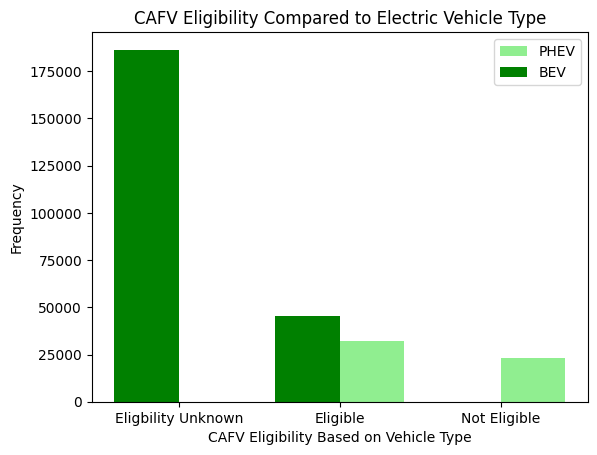

CAFV Eligibility per BEV
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    186374
Clean Alternative Fuel Vehicle Eligible                          45346
Not eligible due to low battery range                                8
Name: count, dtype: int64

CAFV Eligibility per PHEV
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Clean Alternative Fuel Vehicle Eligible    31891
Not eligible due to low battery range      23405
Name: count, dtype: int64

CAFV Eligibility in General
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    186374
Clean Alternative Fuel Vehicle Eligible                          77237
Not eligible due to low battery range                            23413
Name: count, dtype: int64


[1 2]
[0 1 2]


In [103]:
### RELATION BETWEEN CAFV ELIGIBILITY AND ELECTRIC VEHICLE TYPE ###

# Split CAFV eligibility data based on vehicle type
PHEV_df = df_WA[df_WA['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']
BEV_df = df_WA[df_WA['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']

#Tells us how many BEVs have each type of CAFV eligibility
PHEV_CAFV_counts = PHEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
BEV_CAFV_counts = BEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

#Turns it into an array so we can shift each bar to be next to each other on the graph
values_PHEV = np.arange(len(PHEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique()))
values_PHEV[0] = 1
values_PHEV[1] = 2
values_BEV = np.arange(len(BEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].unique()))
width = 0.4
eligibility = ['Eligbility Unknown', 'Eligible', 'Not Eligible']

#Plots them
plt.bar(values_PHEV + width/2, PHEV_CAFV_counts.values, width, color='lightgreen', label = 'PHEV')
plt.bar(values_BEV - width/2, BEV_CAFV_counts.values, width, color='green', label='BEV')

#Labels
plt.title("CAFV Eligibility Compared to Electric Vehicle Type")
plt.ylabel("Frequency")
plt.xlabel("CAFV Eligibility Based on Vehicle Type")

plt.legend()
plt.xticks(values_BEV, eligibility)

plt.show()

print("CAFV Eligibility per BEV")
print(BEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts())
print()
print("CAFV Eligibility per PHEV")
print(PHEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts())
print()
print("CAFV Eligibility in General")
print(df_WA['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts())
print()
print()
print(values_PHEV)
print(values_BEV)

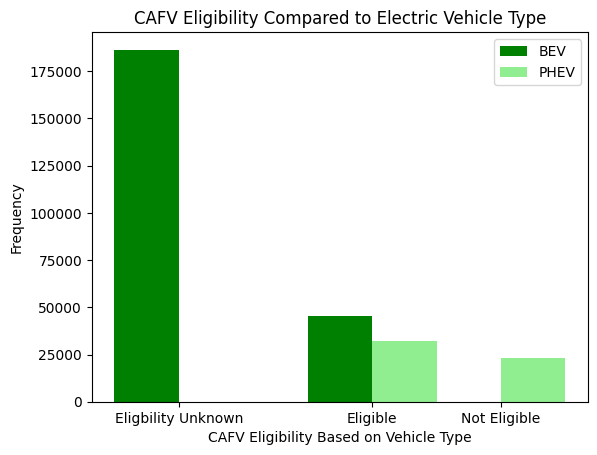

In [119]:
## ANOTHER WAY TO CREATE GRAPH ABOVE, DOESN'T USE NUMPY ARRAY CREATION AND IS MUCH MORE RELIANT ON MANUAL INPUTS ##

# Split CAFV eligibility data based on vehicle type
PHEV_df = df_WA[df_WA['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']
BEV_df = df_WA[df_WA['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']

#Tells us how many BEVs have each type of CAFV eligibility
PHEV_CAFV_counts = PHEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
BEV_CAFV_counts = BEV_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

#Plots them
plt.bar([0, 1.2, 2.0], BEV_CAFV_counts.values, width, color='green', label='BEV')
plt.bar([1.6, 2.4], PHEV_CAFV_counts.values, width, color='lightgreen', label = 'PHEV')

#Labels
plt.title("CAFV Eligibility Compared to Electric Vehicle Type")
plt.ylabel("Frequency")
plt.xlabel("CAFV Eligibility Based on Vehicle Type")

plt.legend()
plt.xticks([0.2, 1.4, 2.2], eligibility)

plt.show()